# Usage of CHIC python module

Brief overview of how to run CHIC to compute neutrino oscillation probabilities and their derivatives.
It assumes that CHIC python bindings have been compiled.

First we import the necessary modules including pychic.

In [3]:
import pychic
import numpy as np
import matplotlib.pyplot as plt

As we are dealing with constant density media, we will restrict this example to long-basline neutrino experiments such as DUNE or HyperK/T2K. For this example we will focus on the three HK detectors for accelerator neutrinos, ND280 at 280 m, IWCD at 1 km, and HK-FD at 295 km from the target.

In [ ]:
detectors = {"ND280": 0.280, "IWCD": 1., "HK-FD": 295.} # detectors and baselines

As for the neutrino energy, we will assume for most of the examples just the peak of the spectrum at 0.6 GeV. However, for the sake of the first illustration plots we will also compute the oscillation probabilities at different energies.

In [6]:
Enu_peak = 0.6 # GeV
Enu = np.linspace(0.1, 1.2, 100)

1. As a first example we will compute the disappearance and appearance oscillation probbailities for all detectors as a function of energy and for neutrinos.

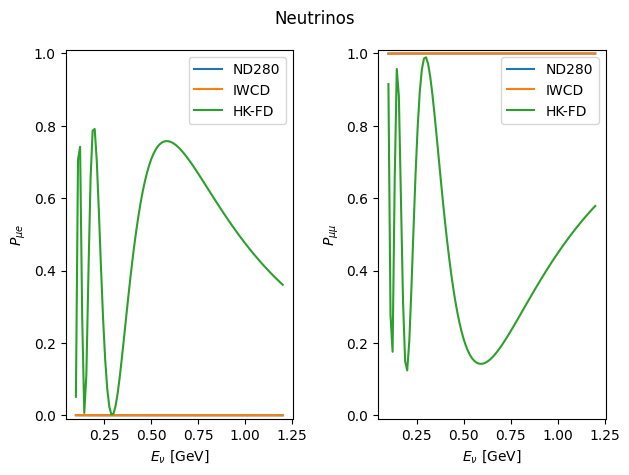

In [ ]:
P_nu_mumu = {"ND280": np.zeros_like(Enu), "IWCD": np.zeros_like(Enu), "HK-FD": np.zeros_like(Enu)}
P_nu_mue = {"ND280": np.zeros_like(Enu), "IWCD": np.zeros_like(Enu), "HK-FD": np.zeros_like(Enu)}

ch = pychic.CHIC() # neutrino is default
for i, E in enumerate(Enu):
    # Take advantage of CHIC caching by looping over baselines inside the energy loop
    for det, L in detectors.items():
        P = ch.compute_oscillations(E, L)
        P_nu_mue[det][i] = P[1][0]
        P_nu_mumu[det][i] = P[1][1]
del ch

fig, (ax1, ax2) = plt.subplots(1, 2)
fig.suptitle("Neutrinos")
for det in detectors.keys():
    ax1.plot(Enu, P_nu_mue[det], label=det)
    ax1.legend()
    ax2.plot(Enu, P_nu_mumu[det], label=det)
    ax2.legend()
ax1.set(xlabel=r"$E_{\nu}$ [GeV]", ylabel=r"$P_{\mu e}$")
ax1.set_ylim([-0.01, 1.01])
ax2.set(xlabel=r"$E_{\nu}$ [GeV]", ylabel=r"$P_{\mu \mu}$")
ax2.set_ylim([-0.01, 1.01])
plt.tight_layout()
plt.show()

2. And for antineutrinos, we have.

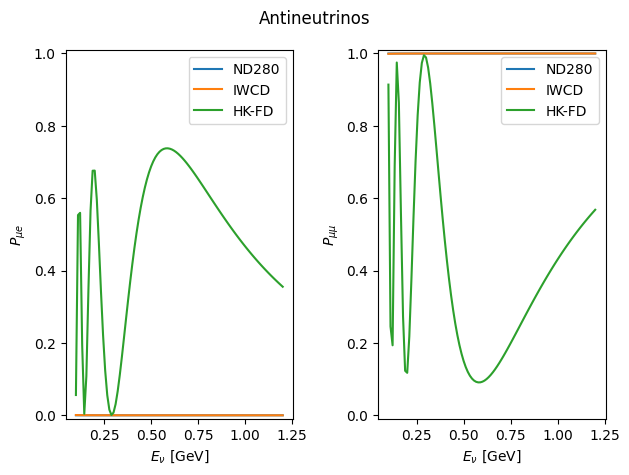

In [ ]:
P_nu_mumu = {"ND280": np.zeros_like(Enu), "IWCD": np.zeros_like(Enu), "HK-FD": np.zeros_like(Enu)}
P_nu_mue = {"ND280": np.zeros_like(Enu), "IWCD": np.zeros_like(Enu), "HK-FD": np.zeros_like(Enu)}

ch = pychic.CHIC("antineutrino")
for i, E in enumerate(Enu):
    # Take advantage of CHIC caching by looping over baselines inside the energy loop
    for det, L in detectors.items():
        P = ch.compute_oscillations(E, L)
        P_nu_mue[det][i] = P[1][0]
        P_nu_mumu[det][i] = P[1][1]
del ch

fig, (ax1, ax2) = plt.subplots(1, 2)
fig.suptitle("Antineutrinos")
for det in detectors.keys():
    ax1.plot(Enu, P_nu_mue[det], label=det)
    ax1.legend()
    ax2.plot(Enu, P_nu_mumu[det], label=det)
    ax2.legend()
ax1.set(xlabel=r"$E_{\nu}$ [GeV]", ylabel=r"$P_{\mu e}$")
ax1.set_ylim([-0.01, 1.01])
ax2.set(xlabel=r"$E_{\nu}$ [GeV]", ylabel=r"$P_{\mu \mu}$")
ax2.set_ylim([-0.01, 1.01])
plt.tight_layout()
plt.show()

3. Instead of computing many points to obtain the oscillation probability as function of neutrino energy, we could take advantage of the derivatives and interpolate from fewer points. For this case, we just show it for HK-FD.

In [37]:
from scipy.interpolate import CubicHermiteSpline

Enu_few = np.geomspace(0.1, 1.2, 10)
P_mumu = np.zeros_like(Enu_few)
P_mue = np.zeros_like(Enu_few)
dP_mumu = np.zeros_like(Enu_few)
dP_mue = np.zeros_like(Enu_few)

dch = pychic.CHICDIFF("neutrino")
for i, E in enumerate(Enu):
    P = dch.compute_oscillations(E, detectors["HK-FD"])
    P_mue[i] = P[1][0]
    P_mumu[i] = P[1][1]
    dP = dch.compute_oscillations_derivatives("E", E, detectors["HK-FD"])
    dP_mue[i] = P[1][0]
    dP_mumu[i] = P[1][1]
del dch

fig, (ax1, ax2) = plt.subplots(1, 2)
fig.suptitle("Neutrinos @ HK-FD -- Interpolation")
ax1.plot(Enu, P_nu_mue["HK-FD"], label="True")
P_mue_interp = CubicHermiteSpline(Enu_few, P_mue, dP_mue)
ax1.plot(Enu_few, P_mue_interp(Enu), label="Interpolation")
ax1.legend()
ax2.plot(Enu, P_nu_mumu["HK-FD"], label="True")
P_mumu_interp = CubicHermiteSpline(Enu_few, P_mumu, dP_mumu)
ax1.plot(Enu_few, P_mumu_interp(Enu), label="Interpolation")
ax2.legend()

ax1.set(xlabel=r"$E_{\nu}$ [GeV]", ylabel=r"$P_{\mu e}$")
ax1.set_ylim([-0.01, 1.01])
ax2.set(xlabel=r"$E_{\nu}$ [GeV]", ylabel=r"$P_{\mu \mu}$")
ax2.set_ylim([-0.01, 1.01])
plt.tight_layout()
plt.show()

ValueError: Unknown parameter: E